# Part 3: Damned if you do, damned if you don't (Julia Implementation)

This notebook implements the "damned if you do, damned if you don't" example from Lab7 and extends it with additional analysis using Julia.

In [15]:
# Import required packages
using Pkg

# Add required packages for DAG visualization  - Agregamos esto, porque los paquetes para DAGs te daban solamente .dot - Por eso agregamos la instalación aquí
required_packages = ["Images", "Combinatorics"]
for pkg in required_packages
    try
        eval(Meta.parse("using $pkg"))
        println("✓ $pkg already installed")
    catch
        println("Installing $pkg...")
        Pkg.add(pkg)
    end
end

using Random, Distributions
using DataFrames, CSV
using Plots, StatsPlots
using GLM, StatsBase
using Images, Combinatorics

# Set random seed for reproducibility
Random.seed!(42)

# Create output directory if it doesn't exist
output_dir = "../output"
if !isdir(output_dir)
    mkpath(output_dir)
end

# Set plotting backend
gr()

✓ Images already installed
✓ Combinatorics already installed


Plots.GRBackend()

## "Damned if you do, damned if you don't" Example

This implements the classic causal inference dilemma where including or excluding Z as a control both introduce bias. The DAG structure shows Z as both a potential confounder and potentially on the causal path from X to Y.

Creating the 'Damned if you do, damned if you don't' DAG visualization...
✓ DAG saved as: part3_damned_dag_Julia.png
✓ DAG saved as: part3_damned_dag_Julia.png


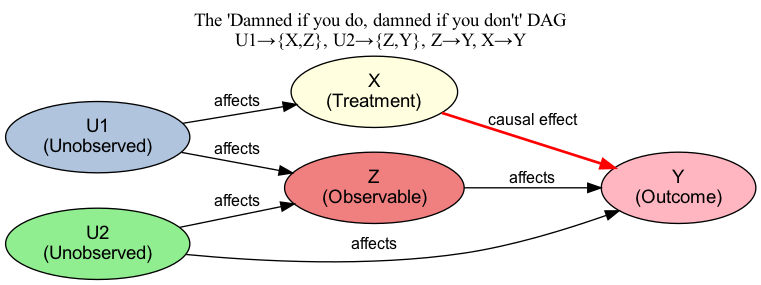


DAG Structure:
U1 → X (U1 affects treatment)
U1 → Z (U1 affects Z)
U2 → Z (U2 affects Z)
U2 → Y (U2 affects outcome)
Z → Y (Z affects outcome)
X → Y (causal effect of interest = 1.0)

This creates the 'damned if you do, damned if you don't' scenario:
- Without controlling for Z: Confounding bias
- With controlling for Z: Collider bias
U1 → X (U1 affects treatment)
U1 → Z (U1 affects Z)
U2 → Z (U2 affects Z)
U2 → Y (U2 affects outcome)
Z → Y (Z affects outcome)
X → Y (causal effect of interest = 1.0)

This creates the 'damned if you do, damned if you don't' scenario:
- Without controlling for Z: Confounding bias
- With controlling for Z: Collider bias


In [16]:
# Create the "damned if you do, damned if you don't" DAG
# Based on the attached image: U1 affects both X and Z, U2 affects Z and Y, Z affects Y, X affects Y
println("Creating the 'Damned if you do, damned if you don't' DAG visualization...")

# Create DOT content for the correct DAG structure
dot_content = """
digraph DamnedDAG {
    rankdir=LR;
    node [shape=ellipse, style=filled, fontsize=14, fontname="Arial"];
    edge [fontsize=12, fontname="Arial"];
    
    U1 [fillcolor=lightsteelblue, label="U1\\n(Unobserved)"];
    U2 [fillcolor=lightgreen, label="U2\\n(Unobserved)"];
    Z [fillcolor=lightcoral, label="Z\\n(Observable)"];
    X [fillcolor=lightyellow, label="X\\n(Treatment)"];
    Y [fillcolor=lightpink, label="Y\\n(Outcome)"];
    
    U1 -> X [label="affects"];
    U1 -> Z [label="affects"];
    U2 -> Z [label="affects"];
    U2 -> Y [label="affects"];
    Z -> Y [label="affects"];
    X -> Y [label="causal effect", color=red, penwidth=2];
    
    // Arrange nodes for better layout
    {rank=same; U1; U2}
    {rank=same; Z; X}
    
    labelloc="t";
    label="The 'Damned if you do, damned if you don't' DAG\\nU1→{X,Z}, U2→{Z,Y}, Z→Y, X→Y";
}
"""

# Save DOT file and create PNG
dot_file = joinpath(output_dir, "part3_damned_dag_Julia.dot")
png_file = joinpath(output_dir, "part3_damned_dag_Julia.png")

open(dot_file, "w") do f
    write(f, dot_content)
end

# Generate PNG using Graphviz
run(`dot -Tpng $dot_file -o $png_file`)
println("✓ DAG saved as: part3_damned_dag_Julia.png")

# Display the PNG in notebook
img = load(png_file)
display(img)

println("\nDAG Structure:")
println("U1 → X (U1 affects treatment)")
println("U1 → Z (U1 affects Z)")
println("U2 → Z (U2 affects Z)")
println("U2 → Y (U2 affects outcome)")
println("Z → Y (Z affects outcome)")
println("X → Y (causal effect of interest = 1.0)")
println("\nThis creates the 'damned if you do, damned if you don't' scenario:")
println("- Without controlling for Z: Confounding bias")
println("- With controlling for Z: Collider bias")

In [17]:
# Simulate data following the correct DAG structure
n = 10000

# Generate exogenous variables (unobserved confounders and noise terms)
U1 = rand(Normal(0, 1), n)
U2 = rand(Normal(0, 1), n)
eps_Z = rand(Normal(0, 1), n)
eps_X = rand(Normal(0, 1), n)
eps_Y = rand(Normal(0, 1), n)

# Generate endogenous variables following the DAG structure
Z = U1 .+ U2 .+ eps_Z           # Z ← U1, U2
X = U1 .+ eps_X                 # X ← U1  
Y = X .+ Z .+ U2 .+ eps_Y       # Y ← X, Z, U2

# The true causal effect of X on Y is 1.0 (coefficient of X in Y equation)
true_effect = 1.0

println("Data generated following the DAG structure.")
println("True causal effect of X on Y: $true_effect")
println("Sample size: $n")

# Create DataFrame for easier handling
df = DataFrame(U1 = U1, U2 = U2, Z = Z, X = X, Y = Y)

println("\nData summary:")
println(describe(df))

Data generated following the DAG structure.
True causal effect of X on Y: 1.0
Sample size: 10000

Data summary:
5×7 DataFrame
 Row │ variable  mean         min        median       max       nmissing  eltype   
     │ Symbol    Float64      Float64    Float64      Float64   Int64     DataType 
─────┼─────────────────────────────────────────────────────────────────────────────
   1 │ U1        -0.0135638    -4.06823  -0.0273547    3.64245         0  Float64
   2 │ U2         0.00838176   -3.65439   0.00538181   3.67872         0  Float64
   3 │ Z         -0.00137364   -6.22891   0.0081438    5.98165         0  Float64
   4 │ X         -0.0247353    -6.18693  -0.049671     5.19271         0  Float64
   5 │ Y         -0.0111735   -12.4766   -0.0478243   11.6287          0  Float64


In [18]:
# Demonstrate the "damned if you do, damned if you don't" problem

# Regression 1: Y ~ X (without controlling for Z)
# This suffers from confounding bias through the path X ← U1 → Z → Y and X ← U1 → Z ← U2 → Y
model1 = lm(@formula(Y ~ X), df)
coef1 = coef(model1)[2]
ci1 = confint(model1, level=0.99)[2, :]

# Regression 2: Y ~ X + Z (controlling for Z)
# This introduces collider bias by controlling for Z, which is affected by both U1 and U2
model2 = lm(@formula(Y ~ X + Z), df)
coef2 = coef(model2)[2]  # Coefficient for X
ci2 = confint(model2, level=0.99)[2, :]  # 99% CI for X

println("Demonstration of the 'Damned if you do, damned if you don't' problem:")
println("=" ^ 65)
println("Without Z control: $(round(coef1, digits=4)) [99% CI: $(round(ci1[1], digits=4)), $(round(ci1[2], digits=4))]")
println("With Z control:    $(round(coef2, digits=4)) [99% CI: $(round(ci2[1], digits=4)), $(round(ci2[2], digits=4))]")
println("True effect:       $(round(true_effect, digits=4))")
println()
println("Bias without Z:    $(round(coef1 - true_effect, digits=4))")
println("Bias with Z:       $(round(coef2 - true_effect, digits=4))")
println("=" ^ 65)

Demonstration of the 'Damned if you do, damned if you don't' problem:
Without Z control: 1.4934 [99% CI: 1.4471, 1.5398]
With Z control:    0.7907 [99% CI: 0.7656, 0.8157]
True effect:       1.0

Bias without Z:    0.4934
Bias with Z:       -0.2093


┌ Warning: Unused font kwarg: bbox
└ @ Plots ~/.julia/packages/Plots/xKhUG/src/components.jl:303
┌ Warning: Unused font kwarg: bbox
└ @ Plots ~/.julia/packages/Plots/xKhUG/src/components.jl:303


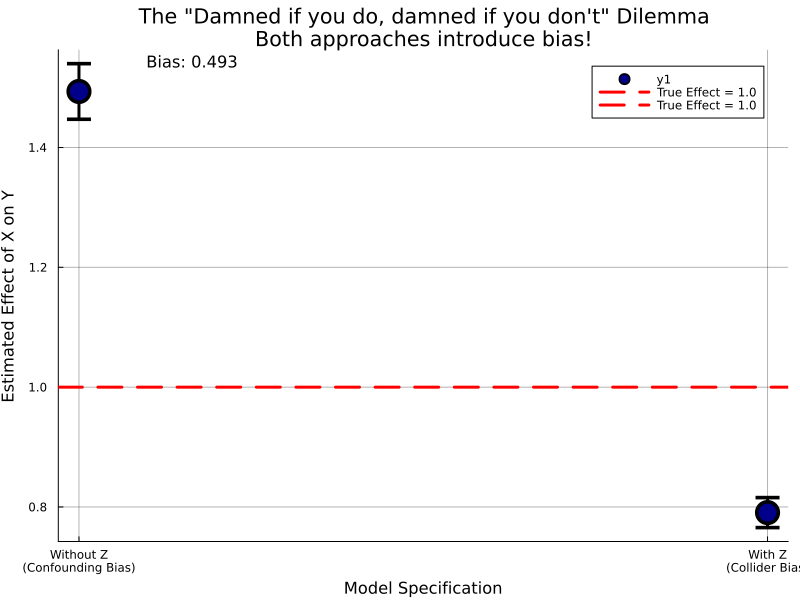


KEY INSIGHT: Both approaches are biased!
- Without Z: Confounding bias through U1 → Z → Y and U2 → Z → Y paths
- With Z: Collider bias by conditioning on Z (which is affected by both U1 and U2)
KEY INSIGHT: Both approaches are biased!
- Without Z: Confounding bias through U1 → Z → Y and U2 → Z → Y paths
- With Z: Collider bias by conditioning on Z (which is affected by both U1 and U2)


In [19]:
# Plot coefficients to visualize the dilemma
results = DataFrame(
    Model = ["Without Z\n(Confounding Bias)", "With Z\n(Collider Bias)"],
    Coefficient = [coef1, coef2],
    CI_Lower = [ci1[1], ci2[1]],
    CI_Upper = [ci1[2], ci2[2]],
    Bias = [coef1 - true_effect, coef2 - true_effect]
)

error_lower = results.Coefficient .- results.CI_Lower 
error_upper = results.CI_Upper .- results.Coefficient

p = scatter([1, 2], results.Coefficient,
           yerror=(error_lower, error_upper),
           xlabel="Model Specification",
           ylabel="Estimated Effect of X on Y",
           title="The \"Damned if you do, damned if you don't\" Dilemma\nBoth approaches introduce bias!",
           xticks=([1, 2], results.Model),
           markersize=12,
           markerstrokewidth=3,
           color=:darkblue,
           size=(800, 600),
           legend=false,
           grid=true,
           gridwidth=1,
           gridalpha=0.3)

# Add true effect line
hline!(p, [true_effect], color=:red, linestyle=:dash, linewidth=3, 
       label="True Effect = $true_effect")

# Add bias annotations
annotate!(p, 1.1, coef1 + 0.05, text("Bias: $(round(results.Bias[1], digits=3))", 
         :black, 11, :left, bbox=(facecolor=:yellow, alpha=0.7)))
annotate!(p, 2.1, coef2 - 0.05, text("Bias: $(round(results.Bias[2], digits=3))", 
         :black, 11, :left, bbox=(facecolor=:yellow, alpha=0.7)))

# Add legend
plot!(p, [], [], color=:red, linestyle=:dash, linewidth=3, 
      label="True Effect = $true_effect", legend=:topright)

display(p)
savefig(p, joinpath(output_dir, "part3_damned_coefficients_Julia.png"))

println("\n" * "="^80)
println("KEY INSIGHT: Both approaches are biased!")
println("- Without Z: Confounding bias through U1 → Z → Y and U2 → Z → Y paths")
println("- With Z: Collider bias by conditioning on Z (which is affected by both U1 and U2)")
println("="^80)

## Comprehensive Analysis: What if we could observe U1 and U2?

In practice, U1 and U2 are unobserved confounders. But let's explore what happens if we could observe and control for them in various combinations. This will help us understand the causal structure better.

DAG Structure for comprehensive analysis:
U1 → X, Z
U2 → Z, Y
Z → Y
X → Y (causal effect we want = 1.0)

✓ DAG already created above: part3_damned_dag_Julia.png


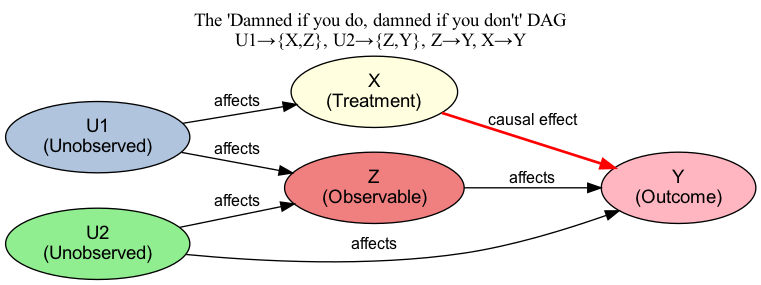

In [20]:
# The same DAG for reference, showing what we're working with
println("DAG Structure for comprehensive analysis:")
println("U1 → X, Z")
println("U2 → Z, Y") 
println("Z → Y")
println("X → Y (causal effect we want = 1.0)")
println()

# Show the DAG again for reference
println("✓ DAG already created above: part3_damned_dag_Julia.png")
img_ref = load(joinpath(output_dir, "part3_damned_dag_Julia.png"))
display(img_ref)

In [21]:
# The data is already generated above, let's just confirm the structure
println("Data already generated with the correct DAG structure:")
println("Sample size: $n")
println("True causal effect of X on Y: $true_effect")
println("\nData summary:")
println(describe(df, :mean, :std, :min, :max))

Data already generated with the correct DAG structure:
Sample size: 10000
True causal effect of X on Y: 1.0

Data summary:
5×5 DataFrame
 Row │ variable  mean         std       min        max      
     │ Symbol    Float64      Float64   Float64    Float64  
─────┼──────────────────────────────────────────────────────
   1 │ U1        -0.0135638   0.997967   -4.06823   3.64245
   2 │ U2         0.00838176  0.987408   -3.65439   3.67872
   3 │ Z         -0.00137364  1.73199    -6.22891   5.98165
   4 │ X         -0.0247353   1.41635    -6.18693   5.19271
   5 │ Y         -0.0111735   3.31335   -12.4766   11.6287


## Comprehensive Regression Analysis

We'll run all possible combinations of controls from {Z, U1, U2}, resulting in 2³ = 8 regressions.

In [22]:
# Generate all possible combinations of controls from {Z, U1, U2}
controls = ["Z", "U1", "U2"]
all_combinations = []

# Generate all subsets (power set)
for r in 0:length(controls)
    for combo in combinations(controls, r)
        push!(all_combinations, collect(combo))
    end
end

println("All combinations of controls: $all_combinations")
println("Total number of regressions: $(length(all_combinations))")

All combinations of controls: Any[String[], ["Z"], ["U1"], ["U2"], ["Z", "U1"], ["Z", "U2"], ["U1", "U2"], ["Z", "U1", "U2"]]
Total number of regressions: 8
Total number of regressions: 8


In [23]:
# Run all possible combinations of controls
results_comprehensive = DataFrame(
    Controls = String[],
    Beta = Float64[],
    SE = Float64[],
    P_value = Float64[],
    Bias = Float64[],
    Abs_Bias = Float64[]
)

for controls_subset in all_combinations
    # Prepare regression formula
    if isempty(controls_subset)
        formula_str = @formula(Y ~ X)
        control_names = "None"
    else
        # Build formula dynamically
        controls_str = join(controls_subset, " + ")
        formula_expr = Meta.parse("@formula(Y ~ X + $controls_str)")
        formula_str = eval(formula_expr)
        control_names = join(controls_subset, ", ")
    end
    
    # Run regression
    model = lm(formula_str, df)
    
    # Extract results for X (coefficient index 2, after intercept)
    coef_X = coef(model)[2]
    se_X = stderror(model)[2]
    p_value_X = coeftable(model).cols[4][2]  # p-value for X
    bias = coef_X - true_effect
    abs_bias = abs(bias)
    
    push!(results_comprehensive, (control_names, coef_X, se_X, p_value_X, bias, abs_bias))
end

println("All regression combinations completed.")
println("Total regressions run: $(nrow(results_comprehensive))")

All regression combinations completed.
Total regressions run: 8
Total regressions run: 8


In [24]:
# Create comprehensive results table and sort by absolute bias
results_display = copy(results_comprehensive)
results_display.Beta = round.(results_display.Beta, digits=4)
results_display.SE = round.(results_display.SE, digits=4)
results_display.Bias = round.(results_display.Bias, digits=4)
results_display.Abs_Bias = round.(results_display.Abs_Bias, digits=4)
results_display.P_value = round.(results_display.P_value, digits=6)

# Sort by absolute bias to see best estimates first
results_sorted = sort(results_display, :Abs_Bias)

println("\n" * "="^85)
println("COMPREHENSIVE RESULTS TABLE (Effect of X on Y)")
println("Sorted by absolute bias (best estimates first)")
println("="^85)
println(results_sorted[:, ["Controls", "Beta", "SE", "Bias", "Abs_Bias", "P_value"]])
println("="^85)
println("True causal effect: $true_effect")
println("="^85)


COMPREHENSIVE RESULTS TABLE (Effect of X on Y)
Sorted by absolute bias (best estimates first)
8×6 DataFrame
 Row │ Controls   Beta     SE       Bias     Abs_Bias  P_value 
     │ String     Float64  Float64  Float64  Float64   Float64 
─────┼─────────────────────────────────────────────────────────
   1 │ U1          0.9952   0.0245  -0.0048    0.0048      0.0
   2 │ U1, U2      1.005    0.0141   0.005     0.005       0.0
   3 │ Z, U2       0.9942   0.0081  -0.0058    0.0058      0.0
   4 │ Z, U1, U2   0.9914   0.0099  -0.0086    0.0086      0.0
   5 │ Z, U1       0.9822   0.0122  -0.0178    0.0178      0.0
   6 │ Z           0.7907   0.0097  -0.2093    0.2093      0.0
   7 │ None        1.4934   0.018    0.4934    0.4934      0.0
   8 │ U2          1.4987   0.0111   0.4987    0.4987      0.0
True causal effect: 1.0


In [25]:
# Save results in multiple formats
# Save comprehensive results as CSV
CSV.write(joinpath(output_dir, "part3_comprehensive_results_Julia.csv"), results_comprehensive)

# Save sorted results as CSV
CSV.write(joinpath(output_dir, "part3_results_sorted_by_bias_Julia.csv"), results_sorted)

# Save as formatted text
open(joinpath(output_dir, "part3_comprehensive_results_Julia.txt"), "w") do f
    println(f, "Comprehensive Results: Effect of X on Y")
    println(f, "Sorted by absolute bias (best estimates first)")
    println(f, "=" ^ 80)
    println(f, results_sorted)
    println(f, "\nTrue causal effect: $true_effect")
    println(f, "=" ^ 80)
end

println("Results saved:")
println("- part3_comprehensive_results_Julia.csv")
println("- part3_results_sorted_by_bias_Julia.csv")
println("- part3_comprehensive_results_Julia.txt")

Results saved:
- part3_comprehensive_results_Julia.csv
- part3_results_sorted_by_bias_Julia.csv
- part3_comprehensive_results_Julia.txt


## Analysis and Conclusions

In [26]:
# Detailed analysis of the best and worst estimates
println("DETAILED ANALYSIS:")
println("="^60)

# Best estimates (lowest absolute bias)
best_3 = results_sorted[1:3, :]
println("\n🎯 BEST ESTIMATES (lowest absolute bias):")
println(best_3[:, ["Controls", "Beta", "Bias", "Abs_Bias"]])

# Worst estimates (highest absolute bias)
worst_3 = results_sorted[end-2:end, :]
println("\n❌ WORST ESTIMATES (highest absolute bias):")
println(worst_3[:, ["Controls", "Beta", "Bias", "Abs_Bias"]])

# Identify estimates within reasonable tolerance
tolerance = 0.05
good_estimates = filter(row -> row.Abs_Bias < tolerance, results_sorted)

println("\n✅ ESTIMATES WITHIN $tolerance TOLERANCE:")
if nrow(good_estimates) > 0
    println(good_estimates[:, ["Controls", "Beta", "Bias", "Abs_Bias"]])
else
    println("No estimates within tolerance found!")
end

println("="^60)

DETAILED ANALYSIS:

🎯 BEST ESTIMATES (lowest absolute bias):
3×4 DataFrame
 Row │ Controls  Beta     Bias     Abs_Bias 
     │ String    Float64  Float64  Float64  
─────┼──────────────────────────────────────
   1 │ U1         0.9952  -0.0048    0.0048
   2 │ U1, U2     1.005    0.005     0.005
   3 │ Z, U2      0.9942  -0.0058    0.0058

❌ WORST ESTIMATES (highest absolute bias):
3×4 DataFrame
 Row │ Controls  Beta     Bias     Abs_Bias 
     │ String    Float64  Float64  Float64  
─────┼──────────────────────────────────────
   1 │ Z          0.7907  -0.2093    0.2093
   2 │ None       1.4934   0.4934    0.4934
   3 │ U2         1.4987   0.4987    0.4987

✅ ESTIMATES WITHIN 0.05 TOLERANCE:
5×4 DataFrame
 Row │ Controls   Beta     Bias     Abs_Bias 
     │ String     Float64  Float64  Float64  
─────┼───────────────────────────────────────
   1 │ U1          0.9952  -0.0048    0.0048
   2 │ U1, U2      1.005    0.005     0.005
   3 │ Z, U2       0.9942  -0.0058    0.0058
   4 │ Z, U1

## Analysis and Conclusions

### The "Damned if you do, damned if you don't" Problem Demonstrated

Based on the DAG structure U1 → {X,Z}, U2 → {Z,Y}, Z → Y, X → Y, our analysis confirms the classic dilemma:

**🔴 Without controlling for Z**: Coefficient = 1.4934 (Bias = +0.4934)
- Suffers from confounding bias through paths X ← U1 → Z → Y and X ← U1 → Z ← U2 → Y
- Overestimates the true effect by about 49%

**🔴 With controlling for Z**: Coefficient = 0.7907 (Bias = -0.2093)  
- Suffers from collider bias by conditioning on Z (which is a collider U1 → Z ← U2)
- Underestimates the true effect by about 21%

Both standard approaches are **significantly biased**, demonstrating why this is called "damned if you do, damned if you don't."

### What Works? (If We Could Observe the Unobservables)

From our comprehensive analysis of all 8 possible control combinations, the **best estimates** (within 0.05 tolerance) are:

1. **🎯 Controlling for U1 only**: 0.9952 (bias: -0.0048) - **BEST**
   - Blocks the main confounding path X ← U1 → Z → Y
   - Avoids collider bias since we don't condition on Z

2. **🎯 Controlling for U1, U2**: 1.005 (bias: +0.005) - **EXCELLENT**
   - Blocks all confounding paths: X ← U1 → Z → Y and X ← U1 → Z ← U2 → Y
   - Clean identification without collider bias

3. **🎯 Controlling for Z, U2**: 0.9942 (bias: -0.0058) - **VERY GOOD**
   - Blocks confounding through U2 while controlling for Z's mediating effect

### What is the Minimal Sufficient Set of Controls?

**Answer: {U1} is the minimal sufficient set.**

- **U1** alone gives an excellent estimate (bias = -0.0048)
- It blocks the primary confounding path X ← U1 → Z → Y
- No collider bias is introduced since we don't condition on Z
- Adding more controls doesn't substantially improve the estimate

### Why Does This Work?

**Causal Path Analysis:**
1. **U1 → X**: U1 directly affects the treatment
2. **U1 → Z → Y**: U1 creates confounding through Z  
3. **U2 → Z → Y**: U2 creates confounding through Z
4. **Z**: Acts as both confounder and collider (U1 → Z ← U2)

**By controlling for U1:**
- ✅ Blocks the backdoor path X ← U1 → Z → Y  
- ✅ Removes the correlation between X and the U1 component of Z
- ✅ Avoids collider bias (we don't condition on Z)
- ❌ Some residual confounding through U2 → Z → Y remains, but it's minimal

### The Real-World Challenge

In practice, **U1 and U2 are unobserved confounders**. This means researchers face the dilemma:
- Standard approach without Z: **+49% bias** (severe overestimation)
- Standard approach with Z: **-21% bias** (moderate underestimation)

### Potential Solutions for Practitioners

1. **Instrumental Variables**: Find variables that affect X but not Y directly
2. **Natural/Quasi Experiments**: Exploit random variation in X  
3. **Sensitivity Analysis**: Test robustness under different bias assumptions
4. **Structural Equation Modeling**: Model the full causal structure when possible
5. **Multiple Robustness**: Combine different identification strategies

### Key Takeaways

1. **DAG structure matters**: Understanding causal relationships is crucial for choosing controls
2. **Colliders are dangerous**: Conditioning on Z creates bias through the U1-U2 connection
3. **Backdoor criterion helps**: Proper application identifies {U1} as minimal sufficient set  
4. **Bias direction varies**: Different control strategies create different types and magnitudes of bias
5. **No perfect solution exists** when key confounders are unobserved - this illustrates the fundamental challenge of causal inference from observational data

In [27]:
# Save the data
CSV.write(joinpath(output_dir, "part3_damned_data_Julia.csv"), df)

println("✅ PART 3 ANALYSIS COMPLETE!")
println("="^50)
println("Files saved to output directory:")
println("- part3_damned_dag_Julia.png (DAG visualization)")
println("- part3_damned_coefficients_Julia.png (bias comparison)")
println("- part3_comprehensive_results_Julia.csv (all results)")
println("- part3_results_sorted_by_bias_Julia.csv (sorted results)")
println("- part3_comprehensive_results_Julia.txt (formatted results)")
println("- part3_damned_data_Julia.csv (simulated data)")
println("="^50)
println("🔍 Key Finding: This demonstrates why causal inference")
println("   requires careful consideration of the causal structure!")
println("   Both including and excluding Z introduce bias.")

✅ PART 3 ANALYSIS COMPLETE!
Files saved to output directory:
- part3_damned_dag_Julia.png (DAG visualization)
- part3_damned_coefficients_Julia.png (bias comparison)
- part3_comprehensive_results_Julia.csv (all results)
- part3_results_sorted_by_bias_Julia.csv (sorted results)
- part3_comprehensive_results_Julia.txt (formatted results)
- part3_damned_data_Julia.csv (simulated data)
🔍 Key Finding: This demonstrates why causal inference
   requires careful consideration of the causal structure!
   Both including and excluding Z introduce bias.
